In [1]:
import sys
sys.path.append("/project01/ndcms/atownse2/ExponentialMixtureModel")

import ROOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tools import scale_out as so
import emm
import bias

Welcome to JupyROOT 6.30/04


In [2]:
# # Load data
x = ROOT.RooRealVar("x", "Diphoton Mass [GeV]", 500, 10_000)
data_tree = emm.get_data(sort_and_index=True, tree=True)
data = ROOT.RooDataSet("mgg", "mgg", ROOT.RooArgSet(x), ROOT.RooFit.Import(data_tree))
n = data.numEntries()
data_mean = data.mean(x)
print(f"Data mean: {data_mean}")

Loaded 5036 diphoton invariant masses from data.
Data mean: 676.7652379849756


In [3]:
# Configuration
x_min, x_max = 500, 3500
x_grid = np.linspace(x_min, x_max, 1000)

# Default
n_seeds = 50
n_toys_per_seed = 100

# Generate seeds
default_seed = 42
np.random.seed(default_seed)
seeds = np.random.randint(0, 10000, size=n_seeds)

In [4]:
# Set up models
toy_models = [
    emm.f1(x),
    emm.f2(x),
    emm.f3(x),
    emm.f4(x),
]

models = [
    emm.f1,
    emm.f2,
    emm.f3,
    emm.f4,
    emm.ExponentialMixtureModel_2,
    emm.ExponentialMixtureModel_3,
    emm.ExponentialMixtureModel_4,
]
print(f"Will be submitting {n_seeds * len(toy_models)} tasks, with {n_toys_per_seed} toys fitting {len(models)} models.")

# Fit toy models to data
for toy_model in toy_models:
    print(f"Fitting toy model: {toy_model.name}")
    toy_model.pdf.fitTo(data)

Will be submitting 200 tasks, with 100 toys fitting 7 models.
Fitting toy model: f_1
Fitting toy model: f_2
Fitting toy model: f_3
Fitting toy model: f_4
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_1_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 1000 convergence for edm < 1 strategy 1
Minuit2Minimizer : Valid minimum - status = 1
FVAL  = 31033.2097955985919
Edm   = 0.000159485240499530157
Nfcn  = 27
p1	  = 5.71808	 +/-  0.898473	(limited)
p2	  = -0.778647	 +/-  0.0667606	(limited)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(f_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       31033.41007 Edm =      0.4026341363 NCalls =      9
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : 31033.41007
  Edm           : 0.4026341363
  Internal parameters:	[   -0.06003605845    -0.1202898824]	
  Internal gradient  :	[      -55.0368949     -36.51043855]	
  Internal covariance matrix:
[[  0.00026610788              0]
 [              0  0.00060350528]]]
Info in <Minuit2>: VariableMetricBuilder Start iterating until Edm is < 0.001 with call limit = 1000
Info in <Minuit2>: VariableMetricBuilder    0 - FCN =       31033.41007 Edm =      0.4026341363 NCalls =      9
Info in <Minuit2>: VariableMetricBuilder    1 - FCN =        31033.2098 Edm =   3.319820566e-06 NCalls =     15
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 0.00459152
Info in <Minuit2>: VariableMetricBuilder After Hessian
I

In [5]:
# Run jobs
tasks = []
for seed in seeds:
    for toy_model in toy_models:
        tasks.append(so.Task(bias.fit_models, x, toy_model, models, seed, n_toys_per_seed, n, x_grid))

# _ = so.run_tasks(
#     tasks,
#     use_condor=True,
#     condor_job_name="bias",
#     env_wrapper=so.run_in_mamba,
#     clear_logs=True
# )

In [6]:
# Load and combine results
results = {toy_model.name: bias.load_results(toy_model, seeds, n_toys_per_seed) for toy_model in toy_models}
# results = {toy_model.name: bias.load_results_CV(toy_model, seeds, n_toys_per_seed, n_folds) for toy_model in toy_models}

In [12]:
# Prune results, use BIC to determine best exponential mixture
pruned_results = {}
for toy_model_name, all_fit_results in results.items():
    pruned_results[toy_model_name] = {}
    for model_name, model_fit_results in all_fit_results.items():
        if "ExponentialMixture" in model_name:
            continue
        pruned_results[toy_model_name][model_name] = model_fit_results

    pruned_results[toy_model_name]["ExponentialMixture (AIC)"] = {}
    pruned_results[toy_model_name]["ExponentialMixture (BIC)"] = {}
    # pruned_results[toy_model_name]["Exponential Mixture (CV)"] = {}
    for i_dataset in model_fit_results.keys():
        best_AIC = np.inf
        best_BIC = np.inf
        best_CV = -np.inf
        for k in [2,3]:
            model_name = f"ExponentialMixture-{k}"
            fit_result = all_fit_results[model_name][i_dataset]
            n_params = 2 * k - 1
            # compute AIC
            aic = 2 * n_params + 2 * fit_result["nll"]
            if aic < best_AIC:
                best_AIC = aic
                pruned_results[toy_model_name]["ExponentialMixture (AIC)"][i_dataset] = fit_result
            # Compute BIC
            bic = fit_result["nll"] + n_params*np.log(n)
            if bic < best_BIC:
                best_BIC = bic
                pruned_results[toy_model_name]["ExponentialMixture (BIC)"][i_dataset] = fit_result
            # # Compute CV LL
            # cv_ll = fit_result["cv_ll"]
            # if cv_ll > best_CV:
            #     best_CV = cv_ll
            #     pruned_results[toy_model_name]["ExponentialMixture (CV)"][i_dataset] = fit_result

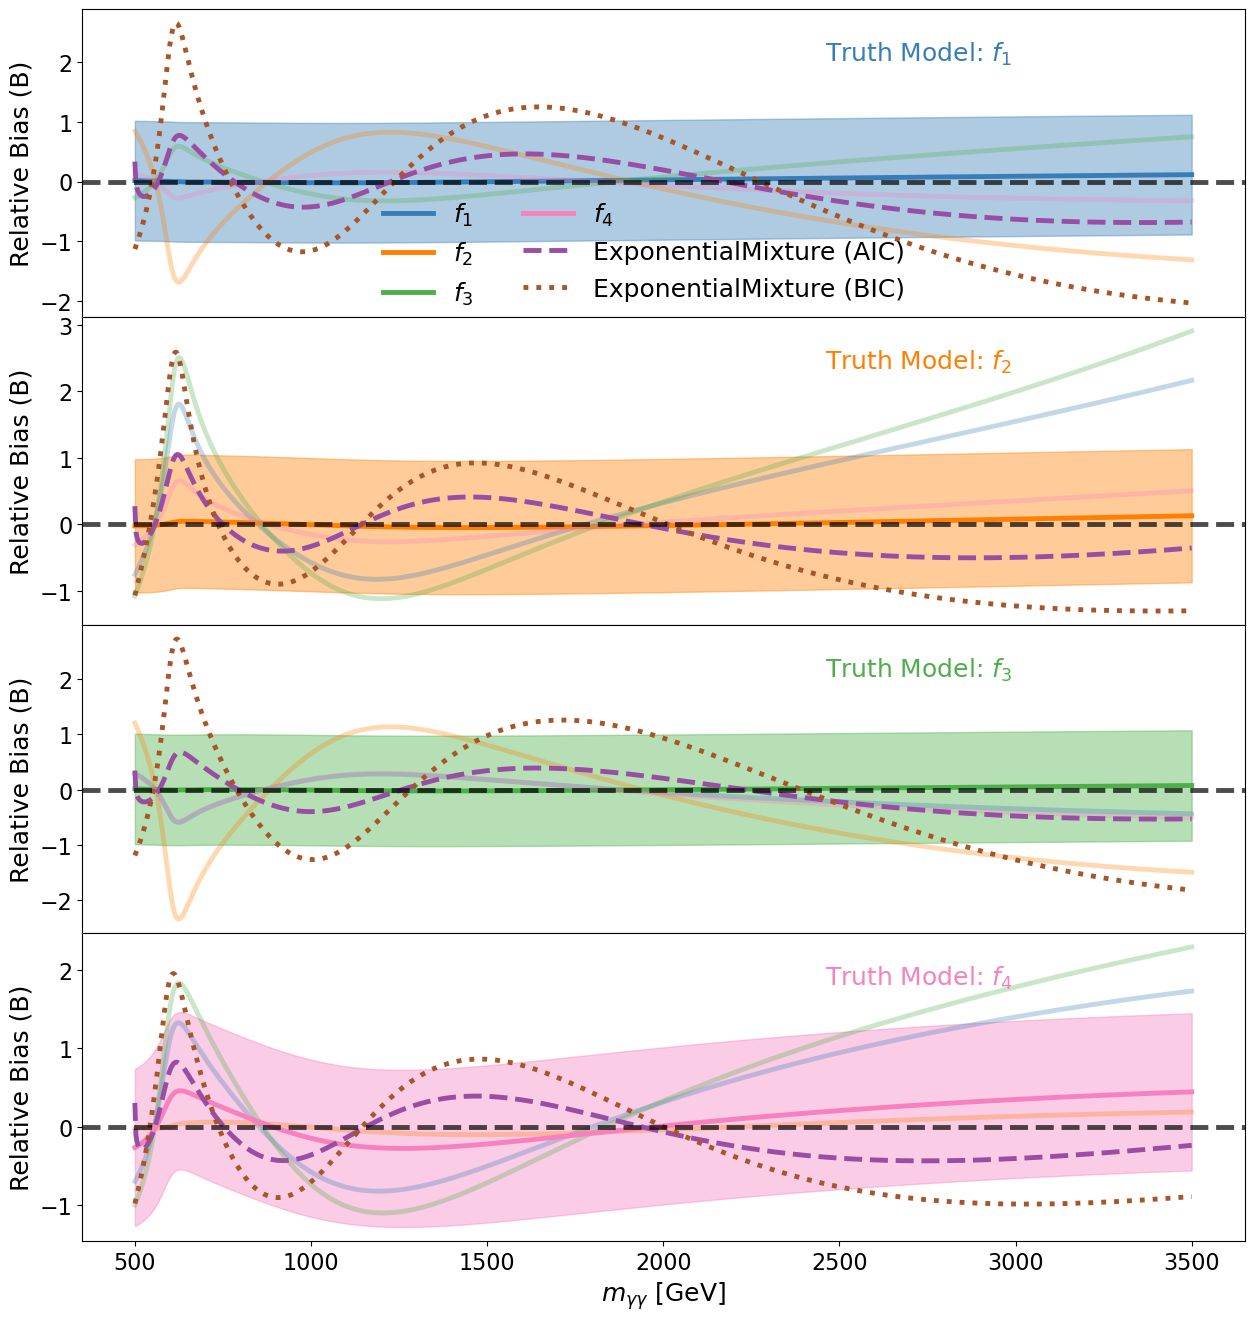

In [14]:
_ = bias.plot_bias(
    x,
    toy_models,
    pruned_results,   # dict keyed by toy_model.name
    x_grid,
    range=(500, 3500),
)